# Setup

In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
import numpy as np
from joblib import dump, load
from itertools import product
import wandb
import geopandas as gpd
from scipy.stats import spearmanr, rankdata
import dask.dataframe as ddf
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from cartopy.io import shapereader

resolution = '50m' 
category = 'cultural'
#name = 'admin_0_countries'

name = 'admin_0_countries'
shpfilename = shapereader.natural_earth(resolution, category, name)

geo_df = gpd.read_file(shpfilename)
togo_shape = geo_df[geo_df["SOV_A3"] == 'TGO' ]  # Search, not case sensitive


survey_data = pd.read_parquet('/data/eop/country_data/TGO/cleaned/full.parquet')
survey_locations = pd.read_csv(
    '/data/togo_anon/surveys/survey2018outcomes.csv',
    usecols=['hhid', 'latitude', 'longitude', 'region', 'prefecture', 'canton']
)
survey_locations = gpd.GeoDataFrame(
    survey_locations, geometry=gpd.points_from_xy(survey_locations.longitude, survey_locations.latitude)
)
def weighted_spearman(x, y, weights):
    x, y, weights = np.asarray(x), np.asarray(y), np.asarray(weights)
    rx, ry = rankdata(x), rankdata(y)
    w_sum = np.sum(weights)
    mean_rx = np.sum(weights * rx) / w_sum
    mean_ry = np.sum(weights * ry) / w_sum
    cov = np.sum(weights * (rx - mean_rx) * (ry - mean_ry)) / w_sum
    std_rx = np.sqrt(np.sum(weights * (rx - mean_rx)**2) / w_sum)
    std_ry = np.sqrt(np.sum(weights * (ry - mean_ry)**2) / w_sum)
    return cov / (std_rx * std_ry)
RANDOM_SEED = 42
XVAL_N_FOLDS = 2
TEST_FRACTION = 0.3
WANDB_PROJECT_NAME = "togo_nontrad_features"


In [2]:
def plot_matched_households(subset, save_path=None):
    survey_locations['in_both'] = survey_locations.hhid.isin(subset.hhid)
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    togo_shape.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
    survey_locations[~survey_locations['in_both']].plot(ax=ax, color='lightblue', markersize=20, alpha=0.7, label='Not in subset')
    survey_locations[survey_locations['in_both']].plot(ax=ax, color='blue', markersize=20, alpha=0.7, label='In subset')
    ax.legend()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [3]:

USE_THREE_WAY_SPLIT = True  # Set to True for holdout validation set
VALIDATION_FRACTION = 0.2  # Only used if USE_THREE_WAY_SPLIT = True
EARLY_STOPPING_ROUNDS = 50


def _split_data(X, y, weights, test_size, random_state, groups=None):
    """Helper function to split data with or without groups."""
    if groups is not None:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        w_train, w_test = weights.iloc[train_idx], weights.iloc[test_idx]
    else:
        X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
            X, y, weights, test_size=test_size, random_state=random_state, shuffle=True
        )
    
    return X_train, X_test, y_train, y_test, w_train, w_test


def model_run(X, y, weights, param_grid, wandb_project_name, wandb_run_name, 
              group_col=None, **kwargs):
    """
    Args:
        group_col: Optional column name in X to use for grouped splitting.
                   If provided, all rows with the same value will be in the same split.
    """
    # Extract groups if specified
    groups = X[group_col].values if group_col is not None else None
    
    # Split based on configuration
    if USE_THREE_WAY_SPLIT:
        # Three-way split: train / validation / test
        X_temp, X_test, y_temp, y_test, w_temp, w_test = _split_data(
            X, y, weights, test_size=TEST_FRACTION, random_state=RANDOM_SEED, groups=groups
        )
        
        # Second split: train vs validation
        groups_temp = X_temp[group_col].values if group_col is not None else None
        val_size = VALIDATION_FRACTION / (1 - TEST_FRACTION)  # Adjust fraction
        
        X_train, X_val, y_train, y_val, w_train, w_val = _split_data(
            X_temp, y_temp, w_temp, test_size=val_size, random_state=RANDOM_SEED, groups=groups_temp
        )
        
        print(f"Three-way split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

        if group_col is not None:
            for df in X_train, X_val, X_test:
                df.drop(columns=group_col, inplace=True)
    else:
        # Two-way split: train / test (validation comes from CV folds)
        X_train, X_test, y_train, y_test, w_train, w_test = _split_data(
            X, y, weights, test_size=TEST_FRACTION, random_state=RANDOM_SEED, groups=groups
        )
        
        print(f"Two-way split: Train={len(X_train)}, Test={len(X_test)}")
        if group_col is not None:
            for df in X_train, X_test:
                df.drop(columns=group_col, inplace=True)

    # 3. Initialize wandb
    wandb.init(
        project=wandb_project_name,
        name=wandb_run_name,
        config={
            "early_stopping": "3-way" if USE_THREE_WAY_SPLIT else "2-way",
            "test_fraction": TEST_FRACTION,
            "validation_fraction": VALIDATION_FRACTION if USE_THREE_WAY_SPLIT else None,
            "xval_folds": XVAL_N_FOLDS,
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            "random_seed": RANDOM_SEED,
            "n_samples_train": len(X_train),
            "n_samples_test": len(X_test),
            "n_samples_total": len(X),
            "n_features": X.shape[1],
            **kwargs
        }
    )


    # Log the param grid to wandb
    wandb.config.update({"param_grid": param_grid})

    print("Starting grid search with early stopping...")
    results = []

    # Convert to numpy arrays for indexing
    X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
    y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train
    w_train_arr = w_train.values if hasattr(w_train, 'values') else w_train

    kf = KFold(n_splits=XVAL_N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    param_combinations = list(product(*param_grid.values()))
    
    for i, params in enumerate(param_combinations):
        param_dict = dict(zip(param_grid.keys(), params))
        fold_scores = []
        fold_iterations = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_arr)):
            X_tr = X_train_arr[train_idx]
            X_val_fold = X_train_arr[val_idx]
            y_tr = y_train_arr[train_idx]
            y_val_fold = y_train_arr[val_idx]
            w_tr = w_train_arr[train_idx]
            w_val_fold = w_train_arr[val_idx]
            
            model = lgb.LGBMRegressor(
                random_state=RANDOM_SEED,
                verbose=-1,
                **param_dict
            )
            
            model.fit(
                X_tr, y_tr,
                sample_weight=w_tr,
                eval_set=[(X_val_fold, y_val_fold)],
                eval_sample_weight=[w_val_fold],
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
            )
            
            # Score on validation fold
            y_val_pred = model.predict(X_val_fold)
            val_mse = mean_squared_error(y_val_fold, y_val_pred, sample_weight=w_val_fold)
            fold_scores.append(-val_mse)
            fold_iterations.append(model.booster_.num_trees())
        
        results.append({
            'params': param_dict,
            'score': np.mean(fold_scores),
            'score_std': np.std(fold_scores),
            'n_iterations': np.mean(fold_iterations)
        })
        
        if (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{len(param_combinations)} combinations")
    
    # 5. Find best parameters
    best_result = max(results, key=lambda x: x['score'])
    best_params = best_result['params']
    print(f"\nBest parameters found: {best_params}")
    print(f"Best CV score (neg MSE): {best_result['score']:.4f}")
    print(f"Average iterations used: {best_result['n_iterations']:.1f}")

    # Log best params to wandb
    wandb.config.update({"best_params": best_params})
    wandb.log({
        "cv/best_score": best_result['score'],
        "cv/avg_iterations": best_result['n_iterations']
    })

    # 6. Train final model on all training data with best parameters
    print("\nTraining final model with best parameters...")
    final_model = lgb.LGBMRegressor(
        random_state=RANDOM_SEED,
        verbose=-1,
        **best_params
    )

    if USE_THREE_WAY_SPLIT:
        # Use validation set for early stopping
        final_model.fit(
            X_train, y_train,
            sample_weight=w_train,
            eval_set=[(X_val, y_val)],
            eval_sample_weight=[w_val],
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
        )
    else:
        # Use test set for early stopping (slight leakage, but necessary without 3-way split)
        final_model.fit(
            X_train, y_train,
            sample_weight=w_train,
            eval_set=[(X_test, y_test)],
            eval_sample_weight=[w_test],
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
        )

    final_iterations = final_model.booster_.num_trees()
    print(f"Final model trained with {final_iterations} iterations")

    # Save results
    dump({'model': final_model, 'best_params': best_params, 'results': results}, 
        'gs_stash.joblib')
    print('Model saved')

    # 7. Evaluate performance
    y_pred_train = final_model.predict(X_train)
    y_pred_test = final_model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train, sample_weight=w_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test, sample_weight=w_test))
    train_r2 = r2_score(y_train, y_pred_train, sample_weight=w_train)
    test_r2 = r2_score(y_test, y_pred_test, sample_weight=w_test)
    train_spearman = weighted_spearman(y_train, y_pred_train, w_train)
    test_spearman = weighted_spearman(y_test, y_pred_test, w_test)
    r2_gap = train_r2 - test_r2

    print("\n=== Performance ===")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"R² Gap: {r2_gap:.4f}")
    print(f"Train Spearman: {train_spearman:.4f}")
    print(f"Test Spearman: {test_spearman:.4f}")

    # Log final metrics to wandb
    wandb.log({
        "final/train_rmse": train_rmse,
        "final/test_rmse": test_rmse,
        "final/train_r2": train_r2,
        "final/test_r2": test_r2,
        "final/r2_gap": r2_gap,
        "final/rmse_ratio": test_rmse / train_rmse,
        "final/n_iterations": final_iterations,
        "final/train_spearman": train_spearman,
        "final/test_spearman": test_spearman
    })

    # Log hyperparameters individually for easier filtering
    for param, value in best_params.items():
        wandb.log({f"best_params/{param}": value})

    print("\n=== Hyperparameters ===")
    for param, values in param_grid.items():
        chosen = best_params[param]
        print(f"{param}: {values} → {chosen}")

    # Create a summary table
    summary_table = wandb.Table(
        columns=["Metric", "Train", "Test", "Gap/Ratio"],
        data=[
            ["RMSE", train_rmse, test_rmse, test_rmse / train_rmse],
            ["R²", train_r2, test_r2, r2_gap]
        ]
    )
    wandb.log({"performance_summary": summary_table})

    # Log all parameter combinations tried (optional, for detailed analysis)
    param_search_table = wandb.Table(
        columns=["learning_rate", "max_depth", "num_leaves", "min_child_samples", 
                "cv_score", "n_iterations"],
        data=[[r['params']['learning_rate'], r['params']['max_depth'], 
            r['params']['num_leaves'], r['params']['min_child_samples'],
            r['score'], r['n_iterations']] for r in results]
    )
    wandb.log({"parameter_search_results": param_search_table})

    # Finish wandb run
    wandb.finish()
    print("\nResults logged to Weights & Biases!")

# Run

## Run with satej's features

In [ ]:
# Inferred from Puneet's work
# Strong trend
architecture = 'resnet50_FMOW_RGB_GASSL'
# Weak trend
# linking_method = 'survey_coordinates'
# No distinguishable trend
zoom = 'z20'

satej_linked_data = dict()

for linking_method in ["1nn_coordinates", "buildings_coordinates", "survey_coordinates"]:

    satellite_unlinked = pd.read_csv(
        f'/projects/didl1/bd_anon/features_eop/satellite/TG/{linking_method}/{zoom}/{architecture}.csv'
    )

    if 'Unnamed: 0' in satellite_unlinked.columns:
        satellite_unlinked.drop(columns='Unnamed: 0', inplace=True)

    satellite_unlinked.columns = [
        f'sat_feat_{col}' if col != 'hhid' else col
        for col in satellite_unlinked.columns
    ]
    satellite_and_survey = survey_data.merge(satellite_unlinked, on='hhid', how='inner')
    satej_linked_data[linking_method] = satellite_and_survey

    satellite = satellite_and_survey[
        satellite_unlinked.columns.tolist() + ['consumption_per_capita_per_day', 'headcount_adjusted_hh_wgt']
    ]
    X = satellite[[col for col in satellite.columns if col.startswith('sat_feat_')]]
    y = satellite['consumption_per_capita_per_day']
    weights = satellite['headcount_adjusted_hh_wgt']

    # 4. Hyperparameter tuning with early stopping
    param_grid = {
        'n_estimators': [1000],
        'learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15, 0.25],
        'max_depth': [2, 3, 5, 7, 10],
        'num_leaves': [5, 7, 15, 30, 50], 
        'min_child_samples': [25, 50, 100, 200, 400]
    }

    model_run(
        X, y, weights, param_grid, WANDB_PROJECT_NAME,
        wandb_run_name='satej_features'+linking_method, linking_method=linking_method
    )

## Run with Mosaiks

In [5]:
mosaiks = pd.read_parquet(
    '/data/eop/country_data/TGO/raw/mosaiks/togo_mosaiks_2019_planet.parquet'
)
mosaiks = gpd.GeoDataFrame(mosaiks, geometry=gpd.points_from_xy(mosaiks.lon, mosaiks.lat))

hhid_with_mosaiks = gpd.sjoin_nearest(survey_locations, mosaiks, 'left')[['hhid', 'geometry'] + [c for c in mosaiks if c.startswith('X_')]]
mosaiks_with_outcomes = hhid_with_mosaiks.merge(
    survey_data[['hhid', 'consumption_per_capita_per_day', 'headcount_adjusted_hh_wgt']],
    on='hhid', how='inner')
mosaiks_with_outcomes[[c for c in mosaiks_with_outcomes if c.startswith('X_')]] = (
    mosaiks_with_outcomes[[c for c in mosaiks_with_outcomes if c.startswith('X_')]].astype('float32')
)

In [6]:
len([col for col in mosaiks_with_outcomes.columns if col.startswith('X_')])

4000

In [ ]:
X = mosaiks_with_outcomes[[col for col in mosaiks_with_outcomes.columns if col.startswith('X_')]]
y = mosaiks_with_outcomes['consumption_per_capita_per_day']
weights = mosaiks_with_outcomes['headcount_adjusted_hh_wgt']

# 4. Hyperparameter tuning with early stopping
param_grid = {
    'n_estimators': [1000],
    'learning_rate': [0.05, 0.08, 0.1, 0.15],
    'max_depth': [2, 3, 5, 7],
    'num_leaves': [4, 7, 15, 30], 
    'min_child_samples': [50, 100, 200, 400]
}
     

model_run(
    X, y, weights, param_grid, WANDB_PROJECT_NAME,
    wandb_run_name='mosaiks'
)

Three-way split: Train=3446, Val=862, Test=1847


Starting grid search with early stopping...
Completed 10/256 combinations
Completed 20/256 combinations
Completed 30/256 combinations
Completed 40/256 combinations
Completed 50/256 combinations
Completed 60/256 combinations
Completed 70/256 combinations
Completed 80/256 combinations
Completed 90/256 combinations
Completed 100/256 combinations
Completed 110/256 combinations
Completed 120/256 combinations
Completed 130/256 combinations
Completed 140/256 combinations
Completed 150/256 combinations
Completed 160/256 combinations
Completed 170/256 combinations
Completed 180/256 combinations
Completed 190/256 combinations
Completed 200/256 combinations
Completed 210/256 combinations
Completed 220/256 combinations
Completed 230/256 combinations
Completed 240/256 combinations
Completed 250/256 combinations

Best parameters found: {'n_estimators': 1000, 'learning_rate': 0.1, 'max_depth': 3, 'num_leaves': 15, 'min_child_samples': 200}
Best CV score (neg MSE): -28.7478
Average iterations used: 78

best_params/learning_rate,▁
best_params/max_depth,▁
best_params/min_child_samples,▁
best_params/n_estimators,▁
best_params/num_leaves,▁
cv/avg_iterations,▁
cv/best_score,▁
final/n_iterations,▁
final/r2_gap,▁
final/rmse_ratio,▁
final/test_r2,▁



Results logged to Weights & Biases!


## Run with AlphaEarth

In [4]:
alpha_earth_features = ddf.read_parquet(
        '/data/eop/country_data/TGO/alpha_earth/EarthEngine-2026-01-12/tabular_no_nans',
).compute()
alpha_earth_features = gpd.GeoDataFrame(
    alpha_earth_features, geometry=gpd.points_from_xy(
        alpha_earth_features.lon, alpha_earth_features.lat
    )
)

In [5]:
survey_locations = pd.read_csv(
    '/data/togo_anon/surveys/survey2018outcomes.csv',
    usecols=['hhid', 'latitude', 'longitude', 'region', 'prefecture', 'canton', 'cluster']
)
survey_locations = gpd.GeoDataFrame(
    survey_locations, geometry=gpd.points_from_xy(survey_locations.longitude, survey_locations.latitude)
)
hhid_with_alpha_earth = gpd.sjoin_nearest(survey_locations, alpha_earth_features, 'left')[
    ['hhid', 'geometry', 'cluster'] + [c for c in alpha_earth_features if c.startswith('band')]
]
alpha_earth_with_outcomes = hhid_with_alpha_earth.merge(
    survey_data[['hhid', 'consumption_per_capita_per_day', 'headcount_adjusted_hh_wgt']],
    on='hhid', how='inner')

In [6]:
group_col = 'cluster'
predictor_cols = [c for c in alpha_earth_features if c.startswith('band')] 
if group_col is not None:
    predictor_cols = predictor_cols + [group_col]

X = alpha_earth_with_outcomes[predictor_cols]
y = alpha_earth_with_outcomes['consumption_per_capita_per_day']
weights = alpha_earth_with_outcomes['headcount_adjusted_hh_wgt']

# 4. Hyperparameter tuning with early stopping
param_grid = {
    'n_estimators': [1000],
    'learning_rate': [0.06, 0.10, 0.15, 0.25],
    'max_depth': [2, 3, 5, 7],
    'num_leaves': [5,7, 15], 
    'min_child_samples': [50, 100, 200, 400, 800]
}

model_run(
    X, y, weights, param_grid, WANDB_PROJECT_NAME, group_col=group_col,
    wandb_run_name='alpha_earth_grouped'
)

Three-way split: Train=3096, Val=1227, Test=1832


/data/tmp/ipykernel_2907210/1761292240.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=group_col, inplace=True)
/data/tmp/ipykernel_2907210/1761292240.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=group_col, inplace=True)
/data/tmp/ipykernel_2907210/1761292240.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=group_col, inplace=True)
wandb: Currently logged in as: selker (s

Starting grid search with early stopping...
Completed 10/240 combinations
Completed 20/240 combinations
Completed 30/240 combinations
Completed 40/240 combinations
Completed 50/240 combinations
Completed 60/240 combinations
Completed 70/240 combinations
Completed 80/240 combinations
Completed 90/240 combinations
Completed 100/240 combinations
Completed 110/240 combinations
Completed 120/240 combinations
Completed 130/240 combinations
Completed 140/240 combinations
Completed 150/240 combinations
Completed 160/240 combinations
Completed 170/240 combinations
Completed 180/240 combinations
Completed 190/240 combinations
Completed 200/240 combinations
Completed 210/240 combinations
Completed 220/240 combinations
Completed 230/240 combinations
Completed 240/240 combinations

Best parameters found: {'n_estimators': 1000, 'learning_rate': 0.1, 'max_depth': 5, 'num_leaves': 7, 'min_child_samples': 100}
Best CV score (neg MSE): -22.5820
Average iterations used: 84.0

Training final model with be

best_params/learning_rate,▁
best_params/max_depth,▁
best_params/min_child_samples,▁
best_params/n_estimators,▁
best_params/num_leaves,▁
cv/avg_iterations,▁
cv/best_score,▁
final/n_iterations,▁
final/r2_gap,▁
final/rmse_ratio,▁
final/test_r2,▁



Results logged to Weights & Biases!


## Run with CDR

In [10]:
cdr_and_survey = pd.read_parquet(
    '/data/eop/country_data/TGO/cleaned/cdr/full.parquet'
)

predictors = [
    col for col in cdr_and_survey.columns 
    if col not in ['hhid', 'consumption_per_capita_per_day', 'headcount_adjusted_hh_wgt']
]

In [ ]:
X = cdr_and_survey[predictors]
y = cdr_and_survey['consumption_per_capita_per_day']
weights = cdr_and_survey['headcount_adjusted_hh_wgt']

# 4. Hyperparameter tuning with early stopping
param_grid = {
    'n_estimators': [1000],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [2, 3, 5,],
    'num_leaves': [4, 7, 15, 30], 
    'min_child_samples': [50, 100, 200]
}

model_run(
    X, y, weights, param_grid, WANDB_PROJECT_NAME,
    wandb_run_name='cdr'
)

Three-way split: Train=2385, Val=597, Test=1279


Starting grid search with early stopping...
Completed 10/144 combinations
Completed 20/144 combinations
Completed 30/144 combinations
Completed 40/144 combinations
Completed 50/144 combinations
Completed 60/144 combinations
Completed 70/144 combinations
Completed 80/144 combinations
Completed 90/144 combinations
Completed 100/144 combinations
Completed 110/144 combinations
Completed 120/144 combinations
Completed 130/144 combinations
Completed 140/144 combinations

Best parameters found: {'n_estimators': 1000, 'learning_rate': 0.05, 'max_depth': 3, 'num_leaves': 7, 'min_child_samples': 100}
Best CV score (neg MSE): -27.6349
Average iterations used: 129.5

Training final model with best parameters...
Final model trained with 249 iterations
Model saved

=== Performance ===
Train RMSE: 3.9759
Test RMSE: 5.2434
Train R²: 0.5581
Test R²: 0.2010
R² Gap: 0.3570
Train Spearman: 0.6804
Test Spearman: 0.5343

=== Hyperparameters ===
n_estimators: [1000] → 1000
learning_rate: [0.03, 0.05, 0.08, 0

best_params/learning_rate,▁
best_params/max_depth,▁
best_params/min_child_samples,▁
best_params/n_estimators,▁
best_params/num_leaves,▁
cv/avg_iterations,▁
cv/best_score,▁
final/n_iterations,▁
final/r2_gap,▁
final/rmse_ratio,▁
final/test_r2,▁



Results logged to Weights & Biases!


## Run with canton ID

In [11]:
survey_cantons = pd.read_csv(
    '/data/togo_anon/surveys/survey2018outcomes.csv',
    usecols=['hhid', 'canton'],
)
survey_cantons.canton = survey_cantons.canton.astype('str')
survey_cantons = survey_data.merge(survey_cantons, on='hhid', how='inner')

In [12]:
# Hyperparameter grid for ElasticNet
param_grid = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],  # Regularization strength - expanded range
    'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]  # 0=Ridge, 1=Lasso, between=ElasticNet
}


def one_hot_encode_canton(train, test, category_col='canton'):
    """
    One-hot encode the canton column using the full set of categories from both train and test.
    """
    # Concatenate, encode, then split
    combined = pd.concat([train[[category_col]], test[[category_col]]])
    combined_encoded = pd.get_dummies(combined, prefix='', prefix_sep='')
    
    train_encoded = combined_encoded.loc[train.index]
    test_encoded = combined_encoded.loc[test.index]
    
    return train_encoded, test_encoded


def run_categorical_elasticnet(df, category_col='canton', 
                               outcome_col='consumption_per_capita_per_day',
                               weight_col='headcount_adjusted_hh_wgt',
                               wandb_run_name='canton_elasticnet',
                               stratify=False):
    """
    Run ElasticNet with one-hot encoded categorical feature and hyperparameter search.
    """
    
    # Prepare data
    X = df[[category_col]]
    y = df[outcome_col].values
    weights = df[weight_col].values
    
    # Create stratifier for train_test_split if needed
    if stratify:
        stratifier = X[category_col].copy()
        singletons = stratifier.value_counts()[stratifier.value_counts() == 1].index
        mask = stratifier.isin(singletons)
        stratifier[mask] = 'other'
        
        # Split with stratification by category
        X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
            X, y, weights, test_size=TEST_FRACTION, random_state=RANDOM_SEED, 
            shuffle=True, stratify=stratifier
        )
    else:
        # Two-way split: train / test
        X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
            X, y, weights, test_size=TEST_FRACTION, random_state=RANDOM_SEED, shuffle=True
        )

    print(f"Two-way split: Train={len(X_train)}, Test={len(X_test)}")
    
    # One-hot encode
    X_train_enc, X_test_enc = one_hot_encode_canton(X_train, X_test, category_col)
    
    # Diagnostic: verify encoding
    print(f"Encoded features shape: {X_train_enc.shape}")
    if not (X_train_enc.sum(axis=1) == 1).all():
        return X_train_enc
    print(f"Each row sums to 1: {(X_train_enc.sum(axis=1) == 1).all()}")
    
    # Initialize wandb
    wandb.init(
        project=WANDB_PROJECT_NAME,
        name=wandb_run_name,
        config={
            "model": "ElasticNet",
            "feature": category_col,
            "test_fraction": TEST_FRACTION,
            "xval_folds": XVAL_N_FOLDS,
            "random_seed": RANDOM_SEED,
            "n_samples_train": len(X_train),
            "n_samples_test": len(X_test),
            "n_samples_total": len(X),
            "n_categories": X_train_enc.shape[1],
        }
    )
    
    # Log the param grid to wandb
    wandb.config.update({"param_grid": param_grid})
    
    print("\nStarting grid search...")
    results = []
    
    # Convert to numpy arrays for indexing
    X_train_arr = X_train_enc.values
    y_train_arr = y_train
    w_train_arr = w_train
    
    # Create stratifier for CV splits from the TRAINING data
    if stratify:
        stratifier_train = X_train[category_col].copy()
        singletons = stratifier_train.value_counts()[stratifier_train.value_counts() == 1].index
        mask = stratifier_train.isin(singletons)
        stratifier_train[mask] = 'other'
        
        kf = StratifiedKFold(n_splits=XVAL_N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    else:
        stratifier_train = None
        kf = KFold(n_splits=XVAL_N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    
    param_combinations = list(product(*param_grid.values()))
    
    for i, params in enumerate(param_combinations):
        param_dict = dict(zip(param_grid.keys(), params))
        fold_scores = []
        
        # Use appropriate split method based on stratify flag
        if stratify:
            splits = kf.split(X_train_arr, stratifier_train)
        else:
            splits = kf.split(X_train_arr)
        
        for fold_idx, (train_idx, val_idx) in enumerate(splits):
            X_tr = X_train_arr[train_idx]
            X_val_fold = X_train_arr[val_idx]
            y_tr = y_train_arr[train_idx]
            y_val_fold = y_train_arr[val_idx]
            w_tr = w_train_arr[train_idx]
            w_val_fold = w_train_arr[val_idx]
            
            model = ElasticNet(
                random_state=RANDOM_SEED,
                max_iter=10000,
                fit_intercept=True,
                **param_dict
            )
            
            model.fit(X_tr, y_tr, sample_weight=w_tr)
            
            # Score on validation fold
            y_val_pred = model.predict(X_val_fold)
            val_mse = mean_squared_error(y_val_fold, y_val_pred, sample_weight=w_val_fold)
            fold_scores.append(-val_mse)
        
        results.append({
            'params': param_dict,
            'score': np.mean(fold_scores),
            'score_std': np.std(fold_scores)
        })
        
        if (i + 1) % 5 == 0:
            print(f"Completed {i + 1}/{len(param_combinations)} combinations")
    
    # Find best parameters
    best_result = max(results, key=lambda x: x['score'])
    best_params = best_result['params']

    print("\n=== Hyperparameters ===")
    for param, values in param_grid.items():
        chosen = best_params[param]
        print(f"{param}: {values} → {chosen}")

    print(f"Best CV score (neg MSE): {best_result['score']:.4f}")
    
    # Log best params to wandb
    wandb.config.update({"best_params": best_params})
    wandb.log({
        "cv/best_score": best_result['score']
    })
    
    # Train final model with best parameters
    print("\nTraining final model with best parameters...")
    final_model = ElasticNet(
        random_state=RANDOM_SEED,
        max_iter=10000,
        fit_intercept=True,
        **best_params
    )
    
    final_model.fit(X_train_enc, y_train, sample_weight=w_train)
    
    # Evaluate performance
    y_pred_train = final_model.predict(X_train_enc)
    y_pred_test = final_model.predict(X_test_enc)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train, sample_weight=w_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test, sample_weight=w_test))
    train_r2 = r2_score(y_train, y_pred_train, sample_weight=w_train)
    test_r2 = r2_score(y_test, y_pred_test, sample_weight=w_test)
    train_spearman = weighted_spearman(y_train, y_pred_train, w_train)
    test_spearman = weighted_spearman(y_test, y_pred_test, w_test)
    r2_gap = train_r2 - test_r2
    
    print("\n" + "=" * 60)
    print("TRAINING SET PERFORMANCE")
    print("=" * 60)
    print(f"Weighted RMSE:            {train_rmse:.4f}")
    print(f"Weighted R²:              {train_r2:.4f}")
    print(f"Spearman Correlation:     {train_spearman:.4f}")
    
    print("\n" + "=" * 60)
    print("TEST SET PERFORMANCE")
    print("=" * 60)
    print(f"Weighted RMSE:            {test_rmse:.4f}")
    print(f"Weighted R²:              {test_r2:.4f}")
    print(f"Spearman Correlation:     {test_spearman:.4f}")
    
    print("\n" + "=" * 60)
    print("MODEL INFO")
    print("=" * 60)
    print(f"R² Gap (train - test):    {r2_gap:.4f}")
    print(f"RMSE Ratio (test/train):  {test_rmse / train_rmse:.4f}")
    print(f"Number of categories:     {X_train_enc.shape[1]}")
    print(f"Non-zero coefficients:    {np.sum(final_model.coef_ != 0)}")
    print(f"Intercept:                {final_model.intercept_:.4f}")
    
    # Log final metrics to wandb
    wandb.log({
        "final/train_rmse": train_rmse,
        "final/test_rmse": test_rmse,
        "final/train_r2": train_r2,
        "final/test_r2": test_r2,
        "final/r2_gap": r2_gap,
        "final/rmse_ratio": test_rmse / train_rmse,
        "final/train_spearman": train_spearman,
        "final/test_spearman": test_spearman,
        "final/n_nonzero_coef": np.sum(final_model.coef_ != 0),
        "final/intercept": final_model.intercept_
    })
    
    # Log hyperparameters individually
    for param, value in best_params.items():
        wandb.log({f"best_params/{param}": value})
    
    print("\n=== Hyperparameters ===")
    for param, values in param_grid.items():
        chosen = best_params[param]
        print(f"{param}: {values} → {chosen}")
    
    # Create summary table
    summary_table = wandb.Table(
        columns=["Metric", "Train", "Test", "Gap/Ratio"],
        data=[
            ["RMSE", train_rmse, test_rmse, test_rmse / train_rmse],
            ["R²", train_r2, test_r2, r2_gap],
            ["Spearman", train_spearman, test_spearman, train_spearman - test_spearman]
        ]
    )
    wandb.log({"performance_summary": summary_table})
    
    # Log all parameter combinations tried
    param_search_table = wandb.Table(
        columns=["alpha", "l1_ratio", "cv_score", "cv_score_std"],
        data=[[r['params']['alpha'], r['params']['l1_ratio'], 
               r['score'], r['score_std']] for r in results]
    )
    wandb.log({"parameter_search_results": param_search_table})
    
    # Show top categories by coefficient magnitude
    coef_df = pd.DataFrame({
        'category': X_train_enc.columns,
        'coefficient': final_model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print("\nTop 10 categories by coefficient magnitude:")
    print(coef_df.head(10))
    
    # Diagnostic: print worst-performing parameter combinations
    print("\n5 worst parameter combinations:")
    worst_results = sorted(results, key=lambda x: x['score'])[:5]
    for r in worst_results:
        print(f"  {r['params']}: {r['score']:.4f}")
    
    wandb.finish()
    print("\nResults logged to Weights & Biases!")
    
    return final_model, best_params, results

In [19]:
final_model, best_params, results = run_categorical_elasticnet(
    survey_cantons, 
    category_col='canton',
    outcome_col='consumption_per_capita_per_day',
    weight_col='headcount_adjusted_hh_wgt',
    wandb_run_name='canton_elasticnet',
    stratify=False
)

Two-way split: Train=4308, Test=1847
Encoded features shape: (4308, 260)
Each row sums to 1: True



Starting grid search...


/home/selker/.conda/envs/leo_base/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.550e+04, tolerance: 7.045e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/selker/.conda/envs/leo_base/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.631e+04, tolerance: 7.077e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of th

Completed 5/35 combinations


/home/selker/.conda/envs/leo_base/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.560e+04, tolerance: 7.045e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/selker/.conda/envs/leo_base/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.641e+04, tolerance: 7.077e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of th

...

Completed 35/35 combinations

=== Hyperparameters ===
alpha: [1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0] → 0.001
l1_ratio: [0.0, 0.25, 0.5, 0.75, 1.0] → 0.0
Best CV score (neg MSE): -26.4694

Training final model with best parameters...


/home/selker/.conda/envs/leo_base/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.446e+04, tolerance: 1.412e+01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(



TRAINING SET PERFORMANCE
Weighted RMSE:            4.9834
Weighted R²:              0.2424
Spearman Correlation:     0.6502

TEST SET PERFORMANCE
Weighted RMSE:            5.3128
Weighted R²:              0.1928
Spearman Correlation:     0.6040

MODEL INFO
R² Gap (train - test):    0.0497
RMSE Ratio (test/train):  1.0661
Number of categories:     260
Non-zero coefficients:    257
Intercept:                3.9750

=== Hyperparameters ===
alpha: [1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0] → 0.001
l1_ratio: [0.0, 0.25, 0.5, 0.75, 1.0] → 0.0

Top 10 categories by coefficient magnitude:
    category  coefficient
32       149     6.758915
34       151     5.674082
39       156     5.367101
37       154     5.190360
36       153     5.108529
38       155     4.852681
209      383     4.615062
30       147     3.729890
4        104     3.426335
35       152     3.111432

5 worst parameter combinations:
  {'alpha': 1.0, 'l1_ratio': 0.5}: -32.7836
  {'alpha': 1.0, 'l1_ratio': 0.75}: -32.7836
 

best_params/alpha,▁
best_params/l1_ratio,▁
cv/best_score,▁
final/intercept,▁
final/n_nonzero_coef,▁
final/r2_gap,▁
final/rmse_ratio,▁
final/test_r2,▁
final/test_rmse,▁
final/test_spearman,▁
final/train_r2,▁



Results logged to Weights & Biases!


# Plot

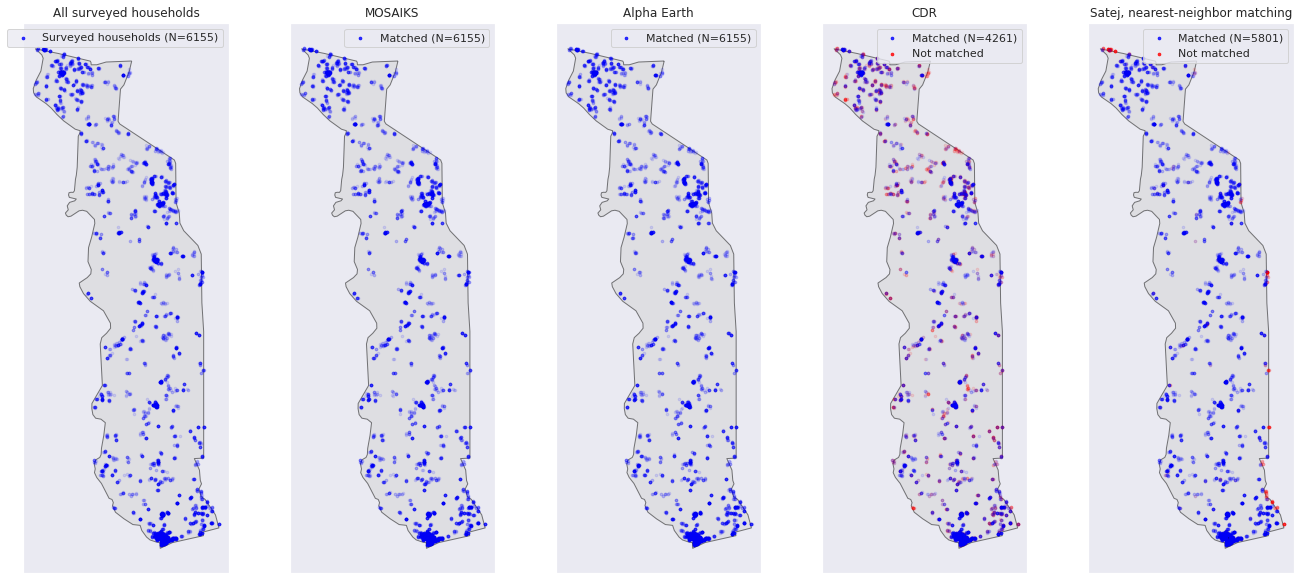

In [29]:
to_plot_matching = {
    'MOSAIKS': mosaiks_with_outcomes, 
    'Alpha Earth': alpha_earth_with_outcomes, 
    'CDR': cdr_and_survey, 
    'Satej, nearest-neighbor matching': satej_linked_data['1nn_coordinates']
}
alpha = 0.1
markersize = 7

fig, axes = plt.subplots(1, len(to_plot_matching) + 1, figsize=(18, 10))

togo_shape.plot(ax=axes[0], color='lightgray', edgecolor='black', alpha=0.5)
survey_locations.plot(
    ax=axes[0], color='blue', markersize=markersize, alpha=alpha, label=f'Surveyed households (N={len(survey_locations)})'
)
legend = axes[0].legend()
for lh in legend.legend_handles:
    lh.set_alpha(0.8)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_title('All surveyed households')

for ax, (name, to_plot) in zip(axes[1:], to_plot_matching.items()):
    togo_shape.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

    survey_locations['in_both'] = survey_locations.hhid.isin(to_plot.hhid)
    # Plot

    if (~survey_locations['in_both']).sum() > 0:
        survey_locations[~survey_locations['in_both']].plot(ax=ax, color='red', markersize=markersize, alpha=alpha, label=f'Not matched')
    survey_locations[survey_locations['in_both']].plot(
        ax=ax, color='blue', markersize=markersize, alpha=alpha, label=f'Matched (N={len(to_plot)})'
    )


    #Reorder legend
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) == 2:
        order = [1, 0]  # Matched first, then Not matched
        legend = ax.legend([handles[i] for i in order], [labels[i] for i in order])
    else:
        legend = ax.legend()
    for lh in legend.legend_handles:
        lh.set_alpha(0.8)
    ax.set_title(f'{name}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()



# Read in from wandb

In [10]:
api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("selker-university-of-california-berkeley/togo_nontrad_features")

#summary_list, config_list, name_list = [], [], []

name_list = []
test_r2_list = []
train_r2_list = []
test_spearman_list = []
train_spearman_list = []
sample_counts = []
for run_record in runs:
    if 'missing correct spearman' in run_record.tags:
        continue

    if 'sufficient_hparam_grid' not in run_record.tags:
        continue
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary)

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    if False:
        config_list.append(
            {k: v for k,v in run_record.config.items()
            if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run_record.name)
    
    history = run_record.history()
    test_r2_list.append(history['final/test_r2'].dropna().values[-1])
    train_r2_list.append(history['final/train_r2'].dropna().values[-1])
    test_spearman_list.append(history['final/test_spearman'].dropna().values[-1])
    train_spearman_list.append(history['final/train_spearman'].dropna().values[-1])

    if 'n_samples_total' in run_record.config:
        sample_counts.append(run_record.config['n_samples_total'])
    else:

        sample_counts.append(run_record.config['n_samples_train'] + run_record.config['n_samples_test'])
   
    
runs_df = pd.DataFrame({
    "name": name_list,
    "test_r2": test_r2_list,
    "train_r2": train_r2_list,
    "test_spearman": test_spearman_list,
    "train_spearman": train_spearman_list,
    "n_samples": sample_counts
    })

In [11]:
runs_df[['name', 'n_samples', 'test_r2', 'train_r2', 'test_spearman', 'train_spearman']].round(2)

,name,n_samples,test_r2,train_r2,test_spearman,train_spearman
0,satej_features1nn_coordinates,4989,0.25,0.38,0.61,0.65
1,satej_featuresbuildings_coordinates,1796,0.18,0.59,0.60,0.83
2,satej_featuressurvey_coordinates,5283,0.19,0.41,0.60,0.64
3,mosaiks,5293,0.23,0.27,0.55,0.61
4,cdr,3664,0.20,0.56,0.53,0.68
5,canton_elasticnet,6155,0.19,0.24,0.60,0.65
6,alpha_earth,5293,0.25,0.29,0.57,0.62
7,alpha_earth_grouped,6155,0.19,0.26,0.58,0.60


In [75]:
runs_df.loc[0, 'summary']

{'_runtime': 1816, '_step': 0, '_timestamp': 1767984435.2982705, '_wandb': {'runtime': 1816}, 'cv/avg_iterations': 52, 'cv/best_score': -29.15825395861108}

In [73]:
runs_df.loc[0, 'config']

{'n_features': 4000,
 'param_grid': {'max_depth': [3, 5, 7],
  'num_leaves': [7, 15, 30],
  'n_estimators': [1000],
  'learning_rate': [0.05, 0.08, 0.1, 0.15],
  'min_child_samples': [50, 100, 200]},
 'xval_folds': 2,
 'best_params': {'max_depth': 7,
  'num_leaves': 15,
  'n_estimators': 1000,
  'learning_rate': 0.05,
  'min_child_samples': 100},
 'random_seed': 42,
 'test_fraction': 0.3,
 'early_stopping': '2-way',
 'n_samples_test': 1847,
 'n_samples_train': 4308,
 'validation_fraction': None,
 'early_stopping_rounds': 50}

In [70]:
runs_df.summary.apply(lambda d: d['linking_method'])

KeyError: 'linking_method'

In [ ]:
def predict_with_categorical_means(train, test, 
                                   category_col='canton',
                                   outcome_col='consumption_per_capita_per_day',
                                   weight_col='headcount_adjusted_hh_wgt'):
    """
    Predict outcome using weighted category means from training data.
    """
    # Compute weighted mean for each category in training set
    category_means = (
        train.groupby(category_col)
        .apply(lambda x: np.average(x[outcome_col], weights=x[weight_col]))
    )
    
    # Compute overall weighted mean for unseen categories
    overall_mean = np.average(train[outcome_col], weights=train[weight_col])
    
    # Make predictions on test set
    test_pred = test[category_col].map(category_means).fillna(overall_mean)
    
    return test_pred, category_means, overall_mean

train, test = train_test_split(survey_cantons, test_size=0.2, random_state=RANDOM_SEED, shuffle=True)
# Use the function
test_predictions, category_means, overall_mean = predict_with_categorical_means(train, test)
test_gt = test['consumption_per_capita_per_day']
test_weights = test['headcount_adjusted_hh_wgt']
train_rmse = np.sqrt(mean_squared_error(test_gt, test_predictions, sample_weight=test_weights))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test, sample_weight=w_test))
train_r2 = r2_score(y_train, y_pred_train, sample_weight=w_train)
test_r2 = r2_score(y_test, y_pred_test, sample_weight=w_test)
train_spearman = spearmanr(y_train, y_pred_train)[0]
test_spearman = spearmanr(y_test, y_pred_test)[0]
r2_gap = train_r2 - test_r2





# For weighted metrics, you'd need to implement custom scoring
# Simple unweighted metrics:
r2 = r2_score(test['consumption_per_capita_per_day'], test_predictions)
rmse = np.sqrt(mean_squared_error(test['consumption_per_capita_per_day'], test_predictions))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"\nNumber of categories in training: {len(category_means)}")
print(f"Overall mean (for unseen categories): {overall_mean:.4f}")

# See the category means
print("\nCategory means:")
print(category_means)



print("\n=== Performance ===")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"R² Gap: {r2_gap:.4f}")
print(f"Train Spearman: {train_spearman:.4f}")
print(f"Test Spearman: {test_spearman:.4f}")

# Log final metrics to wandb
wandb.log({
    "final/train_rmse": train_rmse,
    "final/test_rmse": test_rmse,
    "final/train_r2": train_r2,
    "final/test_r2": test_r2,
    "final/r2_gap": r2_gap,
    "final/rmse_ratio": test_rmse / train_rmse,
    "final/n_iterations": final_iterations,
    "final/train_spearman": train_spearman,
    "final/test_spearman": test_spearman
})

# Log hyperparameters individually for easier filtering
for param, value in best_params.items():
    wandb.log({f"best_params/{param}": value})

print("\n=== Hyperparameters ===")
for param, values in param_grid.items():
    chosen = best_params[param]
    print(f"{param}: {values} → {chosen}")

# Create a summary table
summary_table = wandb.Table(
    columns=["Metric", "Train", "Test", "Gap/Ratio"],
    data=[
        ["RMSE", train_rmse, test_rmse, test_rmse / train_rmse],
        ["R²", train_r2, test_r2, r2_gap]
    ]
)
wandb.log({"performance_summary": summary_table})

# Log all parameter combinations tried (optional, for detailed analysis)
param_search_table = wandb.Table(
    columns=["learning_rate", "max_depth", "num_leaves", "min_child_samples", 
            "cv_score", "n_iterations"],
    data=[[r['params']['learning_rate'], r['params']['max_depth'], 
        r['params']['num_leaves'], r['params']['min_child_samples'],
        r['score'], r['n_iterations']] for r in results]
)
wandb.log({"parameter_search_results": param_search_table})

# Finish wandb run
wandb.finish()
print("\nResults logged to Weights & Biases!")

,hhid,cluster_id,agroeco_zone,residence_region,prefecture,urban_rural,hh_wgt,hh_size,hgender,hage,...,num_rabbits_m,num_poultry_m,nbd_population_m,nbd_dist_town_km_m,latitude_m,longitude_m,altitude_m,consumption_per_capita_per_day,headcount_adjusted_hh_wgt,canton
0,101,1,LomÃ©,Lome Commune,Arrondissement II,Urban,598.235010,3,Male,89,...,1,1,1,0,0,0,0,16.074784,1794.705031,151
1,103,1,LomÃ©,Lome Commune,Arrondissement II,Urban,598.235010,1,Male,38,...,1,1,1,0,0,0,0,51.151363,598.235010,151
2,104,1,LomÃ©,Lome Commune,Arrondissement II,Urban,598.235010,3,Female,54,...,1,1,1,0,0,0,0,12.972587,1794.705031,151
3,105,1,LomÃ©,Lome Commune,Arrondissement II,Urban,598.235010,2,Female,51,...,1,1,1,0,0,0,0,8.986946,1196.470021,151
4,106,1,LomÃ©,Lome Commune,Arrondissement II,Urban,598.235010,1,Male,28,...,1,1,1,0,0,0,0,34.454887,598.235010,151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6150,54008,540,Northern Plains Zone,Savannas,tandjoare,Rural,147.037387,5,Male,51,...,0,0,0,0,0,0,0,1.909102,735.186935,291
6151,54009,540,Northern Plains Zone,Savannas,tandjoare,Rural,147.037387,9,Male,45,...,0,0,0,0,0,0,0,1.090025,1323.336483,291
6152,54010,540,Northern Plains Zone,Savannas,tandjoare,Rural,147.037387,8,Male,40,...,0,0,0,0,0,0,0,1.971903,1176.299096,291
6153,54011,540,Northern Plains Zone,Savannas,tandjoare,Rural,147.037387,5,Male,52,...,0,0,0,0,0,0,0,1.687952,735.186935,291


# Archive

In [ ]:


satellite = pd.read_parquet(
    '/data/eop/country_data/TGO/cleaned/satellite/full.parquet'
)
# 1. Fix random seed
RANDOM_SEED = 42
XVAL_N_FOLDS = 2
TEST_FRACTION = 0.3

# 2. Prepare data and hold out 20%
X = satellite[[col for col in satellite.columns if col.startswith('sat_feat_')]]
y = satellite['consumption_per_capita_per_day']
weights = satellite['headcount_adjusted_hh_wgt']

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=TEST_FRACTION, random_state=RANDOM_SEED, shuffle=True
)

# 3. Hyperparameter tuning with GridSearchCV
param_grid = {
    'lgb__n_estimators': [50, 100, 150],
    'lgb__learning_rate': [0.05, 0.08, 0.1,0.15],
    'lgb__max_depth': [3,5,7],
    'lgb__num_leaves': [7,15,30], 
    'lgb__min_child_samples': [50,100,200]
}

pipeline = Pipeline([
    ('lgb', lgb.LGBMRegressor(random_state=RANDOM_SEED, verbose=-1))
])

grid_search = GridSearchCV(
    pipeline, param_grid, cv=XVAL_N_FOLDS, scoring='neg_mean_squared_error',
    verbose=1, n_jobs=-1, refit=True
)
print("Starting grid search...")
grid_search.fit(X_train, y_train, lgb__sample_weight=w_train)
dump(grid_search, 'gs_stash.joblib') 
del grid_search
print('done and saved')
grid_search = load('gs_stash.joblib')
# 4. Best model is already fitted on entire training set
best_model = grid_search.best_estimator_

# 5. Print performance and hyperparameters
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("\n=== Performance ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train, sample_weight=w_train)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test, sample_weight=w_test)):.4f}")
print(f"Train R²: {r2_score(y_train, y_pred_train, sample_weight=w_train):.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test, sample_weight=w_test):.4f}")

print("\n=== Hyperparameters ===")
for param, values in param_grid.items():
    param_name = param.replace('lgb__', '')
    chosen = grid_search.best_params_[param]
    print(f"{param_name}: {values} → {chosen}")

In [8]:
satellite = pd.read_parquet(
    '/data/eop/country_data/TGO/cleaned/satellite/full.parquet'
)

# 1. Configuration
RANDOM_SEED = 42
XVAL_N_FOLDS = 2
TEST_FRACTION = 0.3
USE_THREE_WAY_SPLIT = False  # Set to True for holdout validation set
VALIDATION_FRACTION = 0.2  # Only used if USE_THREE_WAY_SPLIT = True
EARLY_STOPPING_ROUNDS = 50

# 2. Prepare data
X = satellite[[col for col in satellite.columns if col.startswith('sat_feat_')]]
y = satellite['consumption_per_capita_per_day']
weights = satellite['headcount_adjusted_hh_wgt']

# Split based on configuration
if USE_THREE_WAY_SPLIT:
    # Three-way split: train / validation / test
    X_temp, X_test, y_temp, y_test, w_temp, w_test = train_test_split(
        X, y, weights, test_size=TEST_FRACTION, random_state=RANDOM_SEED, shuffle=True
    )
    X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
        X_temp, y_temp, w_temp, test_size=VALIDATION_FRACTION, 
        random_state=RANDOM_SEED, shuffle=True
    )
    print(f"Three-way split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
else:
    # Two-way split: train / test (validation comes from CV folds)
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, weights, test_size=TEST_FRACTION, random_state=RANDOM_SEED, shuffle=True
    )
    print(f"Two-way split: Train={len(X_train)}, Test={len(X_test)}")

# 3. Hyperparameter tuning with early stopping
param_grid = {
    'n_estimators': [1000],  # Set high, early stopping will find the right number
    'learning_rate': [0.05, 0.08, 0.1, 0.15],
    'max_depth': [3, 5, 7, 11],
    'num_leaves': [7, 15, 30, 45], 
    'min_child_samples': [50, 100, 200]
}

print("Starting grid search with early stopping...")
results = []

# Convert to numpy arrays for indexing
X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train
w_train_arr = w_train.values if hasattr(w_train, 'values') else w_train

if USE_THREE_WAY_SPLIT:
    # Use holdout validation set for all parameter combinations
    param_combinations = list(product(*param_grid.values()))
    
    for i, params in enumerate(param_combinations):
        param_dict = dict(zip(param_grid.keys(), params))
        
        model = lgb.LGBMRegressor(
            random_state=RANDOM_SEED,
            verbose=-1,
            **param_dict
        )
        
        model.fit(
            X_train, y_train,
            sample_weight=w_train,
            eval_set=[(X_val, y_val)],
            eval_sample_weight=[w_val],
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
        )
        
        # Score on validation set
        y_val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, y_val_pred, sample_weight=w_val)
        
        results.append({
            'params': param_dict,
            'score': -val_mse,  # Negative MSE for consistency
            'n_iterations': model.booster_.num_trees()
        })
        
        if (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{len(param_combinations)} combinations")
    
else:
    # Use cross-validation folds for validation
    kf = KFold(n_splits=XVAL_N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    param_combinations = list(product(*param_grid.values()))
    
    for i, params in enumerate(param_combinations):
        param_dict = dict(zip(param_grid.keys(), params))
        fold_scores = []
        fold_iterations = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_arr)):
            X_tr = X_train_arr[train_idx]
            X_val_fold = X_train_arr[val_idx]
            y_tr = y_train_arr[train_idx]
            y_val_fold = y_train_arr[val_idx]
            w_tr = w_train_arr[train_idx]
            w_val_fold = w_train_arr[val_idx]
            
            model = lgb.LGBMRegressor(
                random_state=RANDOM_SEED,
                verbose=-1,
                **param_dict
            )
            
            model.fit(
                X_tr, y_tr,
                sample_weight=w_tr,
                eval_set=[(X_val_fold, y_val_fold)],
                eval_sample_weight=[w_val_fold],
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
            )
            
            # Score on validation fold
            y_val_pred = model.predict(X_val_fold)
            val_mse = mean_squared_error(y_val_fold, y_val_pred, sample_weight=w_val_fold)
            fold_scores.append(-val_mse)
            fold_iterations.append(model.booster_.num_trees())
        
        results.append({
            'params': param_dict,
            'score': np.mean(fold_scores),
            'score_std': np.std(fold_scores),
            'n_iterations': np.mean(fold_iterations)
        })
        
        if (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{len(param_combinations)} combinations")

# 4. Find best parameters
best_result = max(results, key=lambda x: x['score'])
best_params = best_result['params']
print(f"\nBest parameters found: {best_params}")
print(f"Best CV score (neg MSE): {best_result['score']:.4f}")
print(f"Average iterations used: {best_result['n_iterations']:.1f}")

# 5. Train final model on all training data with best parameters
print("\nTraining final model with best parameters...")
final_model = lgb.LGBMRegressor(
    random_state=RANDOM_SEED,
    verbose=-1,
    **best_params
)

if USE_THREE_WAY_SPLIT:
    # Use validation set for early stopping
    final_model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_val, y_val)],
        eval_sample_weight=[w_val],
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
    )
else:
    # Use test set for early stopping (slight leakage, but necessary without 3-way split)
    final_model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_test, y_test)],
        eval_sample_weight=[w_test],
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
    )

print(f"Final model trained with {final_model.booster_.num_trees()} iterations")

# Save results
dump({'model': final_model, 'best_params': best_params, 'results': results}, 
     'gs_stash.joblib')
print('Model saved')
# 4. Load best model
stash = load('gs_stash.joblib')
final_model = stash['model']
best_params = stash['best_params'] 
results = stash['results']

# 6. Evaluate performance
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

print("\n=== Performance ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train, sample_weight=w_train)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test, sample_weight=w_test)):.4f}")
print(f"Train R²: {r2_score(y_train, y_pred_train, sample_weight=w_train):.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test, sample_weight=w_test):.4f}")

print("\n=== Hyperparameters ===")
for param, values in param_grid.items():
    chosen = best_params[param]
    print(f"{param}: {values} → {chosen}")

Two-way split: Train=4300, Test=1843
Starting grid search with early stopping...
Completed 10/192 combinations
Completed 20/192 combinations
Completed 30/192 combinations
Completed 40/192 combinations
Completed 50/192 combinations
Completed 60/192 combinations
Completed 70/192 combinations
Completed 80/192 combinations
Completed 90/192 combinations
Completed 100/192 combinations
Completed 110/192 combinations
Completed 120/192 combinations
Completed 130/192 combinations
Completed 140/192 combinations
Completed 150/192 combinations
Completed 160/192 combinations
Completed 170/192 combinations
Completed 180/192 combinations
Completed 190/192 combinations

Best parameters found: {'n_estimators': 1000, 'learning_rate': 0.1, 'max_depth': 11, 'num_leaves': 30, 'min_child_samples': 100}
Best CV score (neg MSE): -26.8048
Average iterations used: 29.0

Training final model with best parameters...
Final model trained with 23 iterations
Model saved

=== Performance ===
Train RMSE: 4.3393
Test RMS

In [9]:
print(f"Average iterations used: {best_result['n_iterations']:.1f}")

Average iterations used: 29.0


In [ ]:
Stashing
=== Performance ===
Train RMSE: 4.3865
Test RMSE: 5.0659
Train R²: 0.4327
Test R²: 0.2065

=== Hyperparameters ===
n_estimators: [1000] → 1000
learning_rate: [0.05, 0.08, 0.1, 0.15] → 0.1
max_depth: [3, 5, 7] → 7
num_leaves: [7, 15, 30] → 30
min_child_samples: [50, 100, 200] → 100